# DP multi-component workflow (test)

Mirrors `dp_workflow.ipynb` but drives the refactored `src/DP_new.py`.
Key API changes vs. the old two-component `DP`:

- `fit_all` returns **`(dp_parent, dp_components, model_cube)`** instead of L/R arrays.
- `dp_parent`: one scalar row per galaxy (Z, mass, chosen `N_COMP`, BIC/chi2 per N, total flux per line).
- `dp_components`: **tidy/long** table, one row per (target, component, line).
- `bpt_classification` / `estimate_SFR` / `select_dp_sample` consume `dp_components`.
- `plot_fit` overlays every component for a target.

In [1]:
from src.misc import *
from src.SPECTRUM import Spectrum
from src.FITSPECTRUM import FitSpectrum
from src.DP_new import DP
import matplotlib.pyplot as plt
import numpy as np

In [2]:
spectra_data    = fits.open('/Users/hyp0515/data/0715_Spring_BGS_ALL_trimmed.fits')
cigale_data     = fits.open('/Users/hyp0515/data/IronPhysProp_v1.2_extracted.fits')
fastspecfit     = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_fastspecfit.fits')

In [3]:
# new-schema output catalogs (parent + components + model cube live in one FITS each)
filenames = {
    'all' : './catalogs/test_all_multicomp.fits',
    'dps' : './catalogs/test_dps_multicomp.fits',
}

## Build the sample: keep sources with >=1 significant emission line (>5 S/N)

In [4]:
FIT = FitSpectrum()
DP  = DP()

ALL_SPECTRA = Spectrum(spectra_data, cigale_data, fastspecfit, load_targetID=None, subtype_filter='QSO')
print('Total number of spectra:', len(ALL_SPECTRA.targetID))

Data loading and processing took 42.71 seconds.
Total number of spectra: 99812


In [5]:
ALL_SPECTRA = FIT.label_emission_lines(ALL_SPECTRA, 10)
ALL_SPECTRA = FIT.significant_emission_filter(ALL_SPECTRA)
print('After significant-emission filter:', len(ALL_SPECTRA.targetID))

After significant-emission filter: 41891


In [6]:
# --- TEST MODE: thin the sample so a full 1..4-component fit runs quickly ---
# Comment this out for a production run.
ALL_SPECTRA = ALL_SPECTRA.shrink_dataset(25)
print('After shrinking:', len(ALL_SPECTRA.targetID))

After shrinking: 1676


In [7]:
ALL_SPECTRA.df.head()

,TARGETID,RA,DEC,Z,SPECTYPE,LOGM,LOGSFR,OII,Hbeta,OIII,Halpha,NII,SII
0,39627739380056564,177.019312,-1.965308,0.323187,GALAXY,10.452706,0.941032,False,False,False,True,False,False
1,39627739392639280,177.758873,-1.925031,0.243503,GALAXY,10.293514,0.048988,False,False,False,True,False,False
2,39627739401029921,178.353242,-1.887325,0.233979,GALAXY,10.177996,-0.036541,False,False,False,True,False,False
3,39627739409420081,178.903160,-1.939040,0.019938,GALAXY,7.343059,-1.136187,False,False,False,True,False,False
4,39627739422001687,179.589584,-1.983656,0.188073,GALAXY,10.676142,1.441621,False,False,True,True,True,False


## Fit everything
For each target, `fit_dp` fits N = 1..4 velocity components, picks N by minimum BIC,
and emits a scalar parent row + tidy per-(component, line) rows + the best-fit model.

In [8]:
dp_parent, dp_components, model_cube = DP.fit_all(data_class=ALL_SPECTRA, n_jobs=10)
print('parent    :', dp_parent.shape)
print('components:', dp_components.shape)
print('model cube:', model_cube.shape)
print('N_COMP distribution:')
print(dp_parent['N_COMP'].value_counts().sort_index())

100%|██████████| 1676/1676 [02:23<00:00, 11.65it/s]


parent    : (1676, 25)
components: (22990, 13)
model cube: (1676, 7781)
N_COMP distribution:
N_COMP
1    1137
2     466
3      62
4      11
Name: count, dtype: int64


In [9]:
dp_parent.head()

,TARGETID,RA,DEC,Z,LOGM,LOGSFR,N_COMP,BIC_1,CHISQ_1,BIC_2,...,OII3726_FLUX_TOT,OII3729_FLUX_TOT,Hbeta_FLUX_TOT,OIII4959_FLUX_TOT,OIII5007_FLUX_TOT,NII6548_FLUX_TOT,NII6583_FLUX_TOT,Halpha_FLUX_TOT,SII6716_FLUX_TOT,SII6731_FLUX_TOT
0,39627739380056564,177.019318,-1.965308,0.323187,10.452706,0.941032,1,945.361572,884.301453,969.563660,...,6.859123,9.129447,5.789403,3.119176,9.447976,4.564665,13.997517,34.080860,6.515172,4.070829
1,39627739392639280,177.758865,-1.925031,0.243503,10.293513,0.048988,1,885.808044,825.218140,938.303833,...,1.376145,1.831640,1.993784,0.284189,0.860808,1.376854,4.222114,9.879091,1.380125,1.373865
2,39627739401029921,178.353241,-1.887325,0.233979,10.177996,-0.036541,1,1087.748779,1027.689209,1113.684570,...,6.684204,8.896631,6.437490,0.978536,2.963984,4.624796,14.181906,37.062889,6.013061,3.212684
3,39627739409420081,178.903152,-1.939040,0.019938,7.343059,-1.136187,1,749.866028,691.035767,802.924988,...,0.000218,0.000290,0.000196,0.000093,0.000283,0.000024,0.000073,0.000597,0.000099,0.000039
4,39627739422001687,179.589584,-1.983656,0.188073,10.676142,1.441621,4,1294.272095,1234.166992,1134.404297,...,20.621372,27.446909,47.119862,39.422916,119.411896,39.033951,119.697357,153.985596,29.397423,25.571997


In [10]:
# tidy long table: one row per (TARGETID, COMP_IDX, LINE)
dp_components.head(30)

,TARGETID,N_COMP,COMP_IDX,LINE,LAM0,DV,SIGMA,AMP,FLUX,FLUX_ERR,SNR,SIG,NOISE3
0,39627739380056564,1,0,OII3726,3727.091797,0.0,95.701317,2.299913,6.859123,0.944579,1.983038,False,1.037669e+01
1,39627739380056564,1,0,OII3729,3729.875488,0.0,95.701317,3.058884,9.129447,1.257228,2.637441,False,1.038444e+01
2,39627739380056564,1,0,Hbeta,4862.690918,0.0,95.701317,1.487887,5.789403,1.311208,1.907413,False,9.105639e+00
3,39627739380056564,1,0,OIII4959,4960.294922,0.0,95.701317,0.785860,3.119176,0.416646,1.046136,False,8.944854e+00
4,39627739380056564,1,0,OIII5007,5008.239746,0.0,95.701317,2.357580,9.447976,1.262020,3.138407,True,9.031312e+00
5,39627739380056564,1,0,NII6548,6549.858887,0.0,95.701317,0.870943,4.564665,0.331004,1.012800,False,1.352093e+01
6,39627739380056564,1,0,NII6583,6585.278320,0.0,95.701317,2.656377,13.997517,1.015021,3.089041,True,1.359404e+01
7,39627739380056564,1,0,Halpha,6564.631836,0.0,95.701317,6.488033,34.080860,1.515096,7.544786,True,1.355142e+01
8,39627739380056564,1,0,SII6716,6718.294434,0.0,95.701317,1.211936,6.515172,2.124237,1.304206,False,1.498652e+01
9,39627739380056564,1,0,SII6731,6732.667969,0.0,95.701317,0.755629,4.070829,1.324980,0.813158,False,1.501859e+01


## Persist to FITS and round-trip

In [11]:
DP.get_catalog(dp_parent, dp_components, model_cube, fname=filenames['all'])
dp_parent, dp_components, model_cube = DP.extract_fits_data(filenames['all'])
print('reloaded:', dp_parent.shape, dp_components.shape, model_cube.shape)

reloaded: (1676, 25) (22990, 13) (1676, 7781)


## Per-component science: BPT and SFR
Both now return one result **per component** instead of a fixed L/R pair.

In [12]:
bpt = DP.bpt_classification(dp_components)
# attach the class back onto the component rows
dp_components = dp_components.merge(bpt, on=['TARGETID', 'COMP_IDX'], how='left')
bpt.head(10)

/Users/hyp0515/master_project/code/main/nature_of_DP/src/DP_new.py:272: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(classify)


,TARGETID,COMP_IDX,BPT
0,39627739380056564,0,4
1,39627739392639280,0,1
2,39627739401029921,0,1
3,39627739409420081,0,1
4,39627739422001687,0,1
5,39627739422001687,1,16
6,39627739422001687,2,4
7,39627739422001687,3,4
8,39627739434585332,0,16
9,39627739434585332,1,4


In [13]:
per_comp_sfr, dp_parent = DP.estimate_SFR(dp_components, dp_parent)
print('total SFR written to parent as LOGSFR_FIT')
per_comp_sfr.head()

/Users/hyp0515/master_project/code/main/nature_of_DP/src/misc.py:164: RuntimeWarning: overflow encountered in scalar power
  flux_intrinsic = flux_halpha / (10**(A_halpha/-2.5)) * 1e-17
/Users/hyp0515/master_project/code/main/nature_of_DP/src/DP_new.py:297: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(comp_sfr)


total SFR written to parent as LOGSFR_FIT


,TARGETID,COMP_IDX,SFR,LOGSFR
0,39627739380056564,0,6.016467e+00,0.779342
1,39627739392639280,0,5.452826e-01,-0.263378
2,39627739401029921,0,2.750262e+00,0.439374
3,39627739409420081,0,3.794974e-08,-7.420791
4,39627739422001687,0,1.468743e+00,0.166946


## Select the multi-component (DP+) sample
A galaxy qualifies when its best model has >1 component AND >=2 components are
significantly detected (`SIG`) in the same line.

In [14]:
dp_sample = DP.select_dp_sample(dp_parent, dp_components)
print('DP+ candidates:', len(dp_sample), '/', len(dp_parent))
# save the DP+ subset (parent rows + their component rows + their model slices)
mask = dp_parent['TARGETID'].isin(dp_sample['TARGETID'])
DP.get_catalog(dp_sample,
               dp_components[dp_components['TARGETID'].isin(dp_sample['TARGETID'])],
               model_cube[mask.to_numpy()],
               fname=filenames['dps'])
dp_sample.head()

DP+ candidates: 521 / 1676


,TARGETID,RA,DEC,Z,LOGM,LOGSFR,N_COMP,BIC_1,CHISQ_1,BIC_2,...,OII3729_FLUX_TOT,Hbeta_FLUX_TOT,OIII4959_FLUX_TOT,OIII5007_FLUX_TOT,NII6548_FLUX_TOT,NII6583_FLUX_TOT,Halpha_FLUX_TOT,SII6716_FLUX_TOT,SII6731_FLUX_TOT,LOGSFR_FIT
4,39627739422001687,179.589584,-1.983656,0.188073,10.676142,1.441621,4,1294.272095,1234.166992,1134.404297,...,27.446909,47.119862,39.422916,119.411896,39.033951,119.697357,153.985596,29.397423,25.571997,0.740248
5,39627739434585332,180.400314,-1.994369,0.225557,10.863021,-2.923037,2,948.392761,888.064087,926.903809,...,17.884418,11.824846,30.851311,93.448532,14.352633,44.012257,58.672550,20.370749,14.760737,0.484839
6,39627739447171255,181.248245,-1.972162,0.117209,9.438264,0.214659,2,1967.040894,1907.412354,957.020508,...,78.024757,76.166237,39.335133,119.146004,15.288704,46.882710,276.441193,39.839527,32.974308,0.102582
7,39627739463945713,182.163559,-1.906823,0.178180,9.985445,-0.083484,2,965.923096,905.817993,930.007202,...,10.139107,13.201367,1.520878,4.606735,7.682859,23.559437,70.445793,14.417344,9.652662,0.441066
8,39627739480722548,183.125961,-1.907327,0.167044,10.255055,1.334479,2,1337.082520,1277.034302,933.558472,...,12.819761,31.538918,2.440744,7.393007,16.495340,50.582851,133.715881,17.024639,14.584820,0.447201


## Eyeball a fit
Overlay data, total model, and every component for one target.

plotting TARGETID 39627758246036235  N_COMP = 3


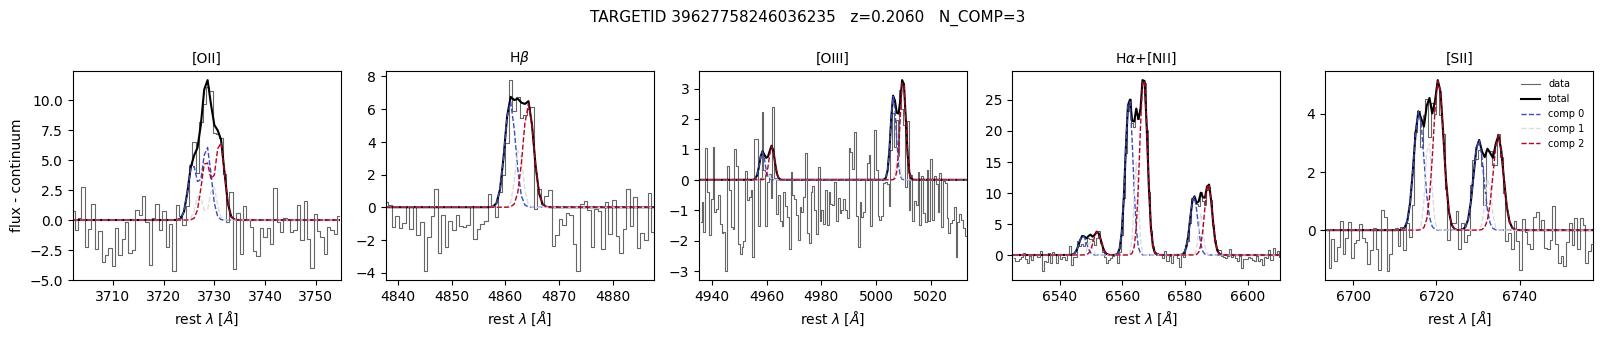

In [42]:
# prefer a multi-component target if we found one
if len(dp_sample):
    tid = int(dp_sample.sort_values('N_COMP', ascending=False)['TARGETID'].iloc[36])
else:
    tid = int(dp_parent['TARGETID'].iloc[0])
print('plotting TARGETID', tid, ' N_COMP =', int(dp_parent.loc[dp_parent['TARGETID']==tid, 'N_COMP'].iloc[0]))
fig, axes = DP.plot_fit(ALL_SPECTRA, dp_parent, dp_components, id=tid)
plt.show()

## Inspect the schema

In [26]:
print('parent columns:')
print(list(dp_parent.columns))
print()
print('component columns:')
print(list(dp_components.columns))

parent columns:
['TARGETID', 'RA', 'DEC', 'Z', 'LOGM', 'LOGSFR', 'N_COMP', 'BIC_1', 'CHISQ_1', 'BIC_2', 'CHISQ_2', 'BIC_3', 'CHISQ_3', 'BIC_4', 'CHISQ_4', 'OII3726_FLUX_TOT', 'OII3729_FLUX_TOT', 'Hbeta_FLUX_TOT', 'OIII4959_FLUX_TOT', 'OIII5007_FLUX_TOT', 'NII6548_FLUX_TOT', 'NII6583_FLUX_TOT', 'Halpha_FLUX_TOT', 'SII6716_FLUX_TOT', 'SII6731_FLUX_TOT', 'LOGSFR_FIT']

component columns:
['TARGETID', 'N_COMP', 'COMP_IDX', 'LINE', 'LAM0', 'DV', 'SIGMA', 'AMP', 'FLUX', 'FLUX_ERR', 'SNR', 'SIG', 'NOISE3', 'BPT']
